IMPORTING ALL REQUIRED LIBRARIES AND MODULES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,classification_report,confusion_matrix,roc_auc_score

In [3]:
df = pd.read_csv("data/churn_data.csv")
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["TotalCharges"].dtype

dtype('O')

In [ ]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


by the above value counts we understand that the data set is imbalance


In [ ]:
### percentage of the values in churn
df["Churn"].value_counts()*100/len(df)

,count
Churn,
No,73.463013
Yes,26.536987


In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"] , errors = "coerce")
df["TotalCharges"].dtype

dtype('float64')

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df["TotalCharges"].fillna(df["TotalCharges"].mean() , inplace = True)
df.isnull().sum()

/tmp/ipykernel_7025/1999692977.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].mean() , inplace = True)


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.drop(columns = ["customerID"] , inplace = True , axis = 0)

PERFORMING THE EDA

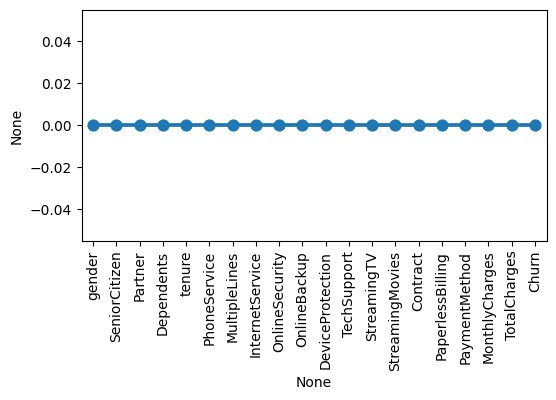

In [ ]:
missing = df.isnull().sum()*100/len(df)
plt.figure(figsize = (6,3))
sns.pointplot(x = missing.index , y = missing)
plt.xticks(rotation = 90)
plt.show()

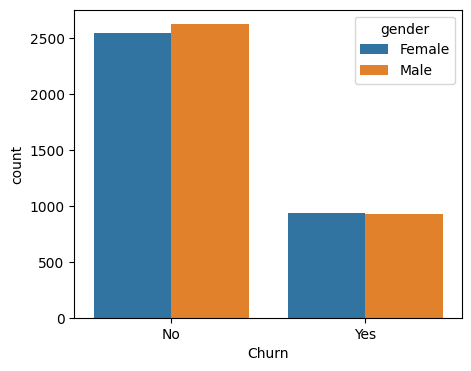

In [ ]:
plt.figure(figsize = (5,4))
sns.countplot(x = df["Churn"] , data = df , hue = "gender")
plt.show()

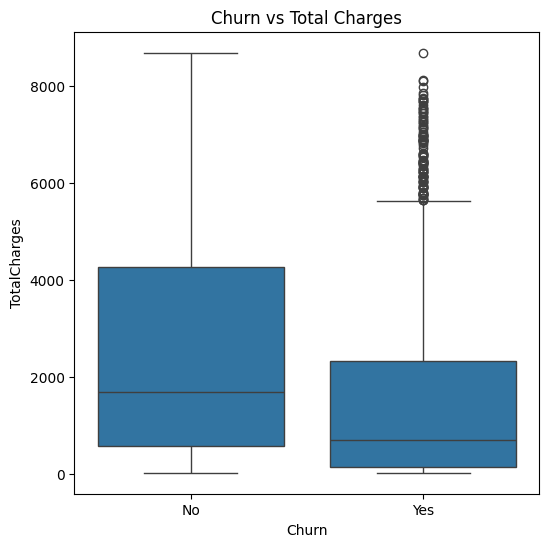

In [ ]:
plt.figure(figsize=(6,6))
sns.boxplot(x="Churn", y="TotalCharges", data=df)
plt.title("Churn vs Total Charges")
plt.show()

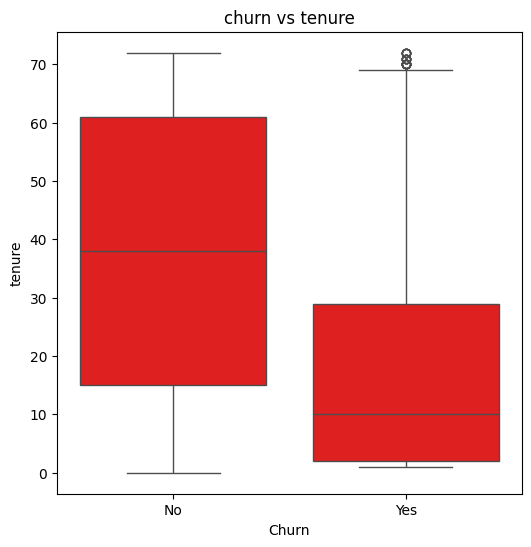

In [ ]:
plt.figure(figsize = (6,6))

sns.boxplot(x = df["Churn"] , y = df["tenure"] , color = "red" , data = df)

plt.title("churn vs tenure")

plt.show()

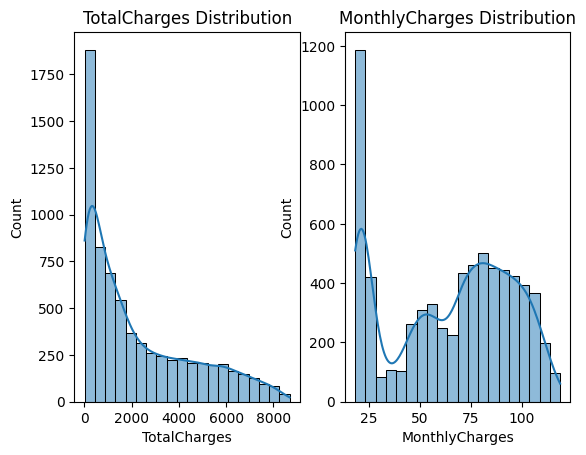

In [ ]:
plt.subplot(1,2,1)
sns.histplot(x = df["TotalCharges"] , kde = True , bins = 20)
plt.title("TotalCharges Distribution")

plt.subplot(1,2,2)
sns.histplot(x = df["MonthlyCharges"] , kde = True , bins = 20)
plt.title("MonthlyCharges Distribution")
plt.show()

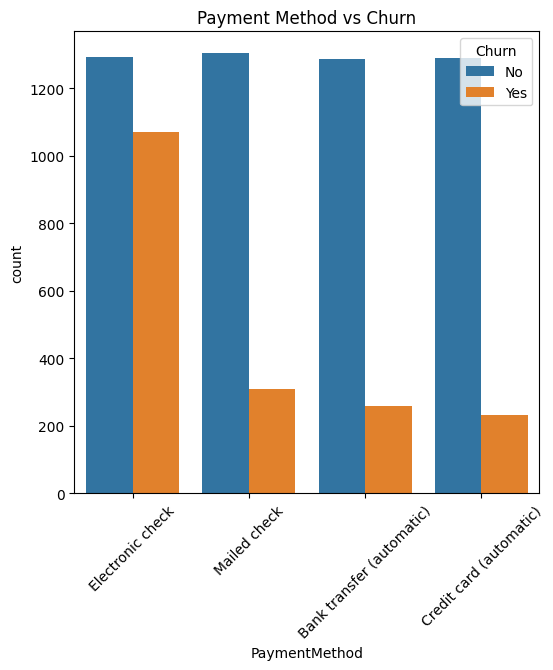

In [ ]:
plt.figure(figsize = (6,6))

sns.countplot(x = df["PaymentMethod"] , hue = df["Churn"] , data = df)
plt.xticks(rotation=45)

plt.title("Payment Method vs Churn")

plt.show()

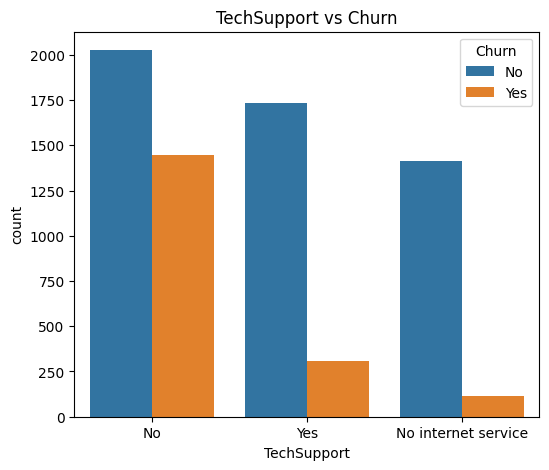

In [ ]:
plt.figure(figsize = (6,5))

sns.countplot(x = df["TechSupport"] , hue = df["Churn"] , data = df)

plt.title("TechSupport vs Churn")

plt.show()

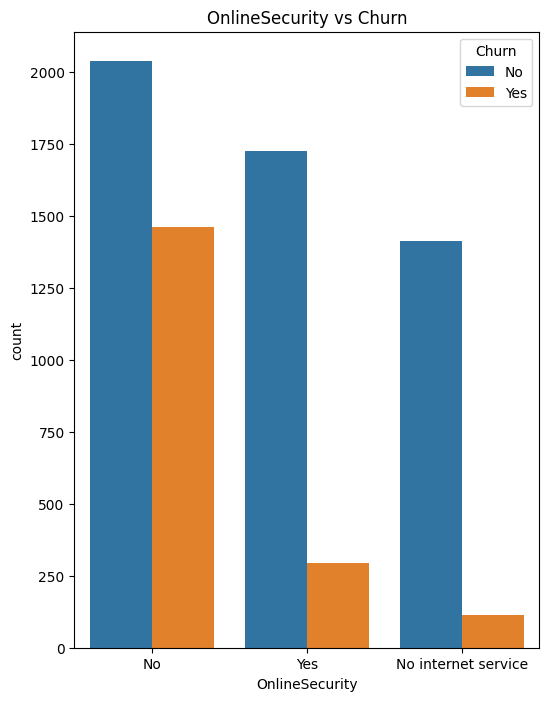

In [ ]:
plt.figure(figsize = (6,8))

sns.countplot(x = df["OnlineSecurity"] , hue = df["Churn"] , data = df)

plt.title("OnlineSecurity vs Churn")

plt.show()

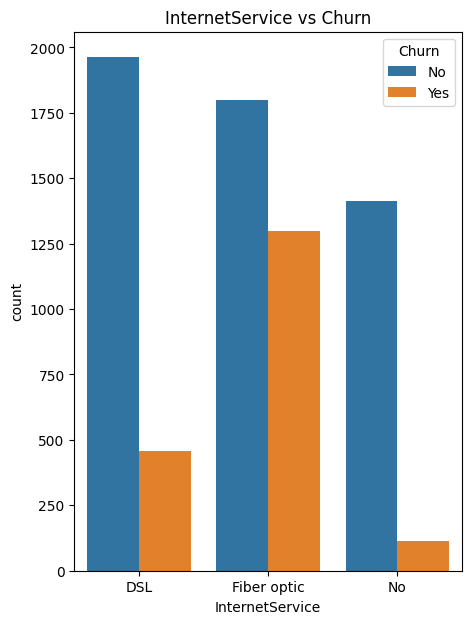

In [ ]:
plt.figure(figsize = (5,7))

sns.countplot(x = df["InternetService"] , hue = df["Churn"] , data = df)

plt.title("InternetService vs Churn")

plt.show()

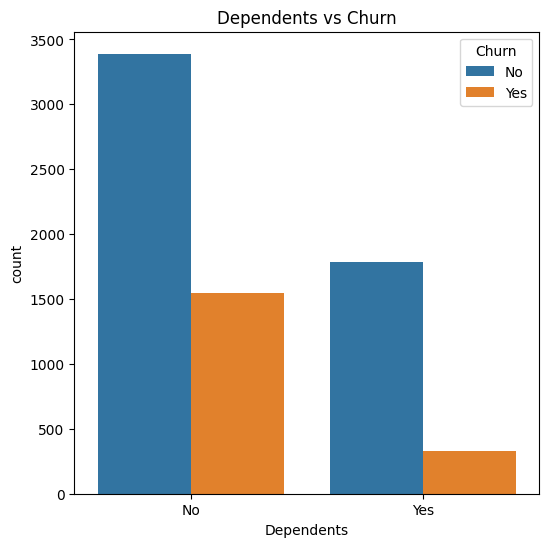

In [ ]:
plt.figure(figsize = (6,6))

sns.countplot(x = df["Dependents"] , hue = df["Churn"] , data = df)

plt.title("Dependents vs Churn")

plt.show()

PERFORMING THE FEATURE ENGINEERING AND SCALING


In [ ]:
df["HighMonthlyCharges"] = np.where(df["MonthlyCharges"] > 70 , 1 , 0).astype(int)

In [ ]:
df["TotalServices"] = (
    (df["PhoneService"] == "Yes").astype(int) +
    (df["OnlineSecurity"] == "Yes").astype(int) +
    (df["TechSupport"] == "Yes").astype(int) +
    (df["StreamingTV"] == "Yes").astype(int) +
    (df["StreamingMovies"] == "Yes").astype(int)
)

In [ ]:
df.groupby("TotalServices")["Churn"].value_counts()

TotalServices  Churn
0              No         77
               Yes        54
1              No       2018
               Yes       639
2              No        911
               Yes       499
3              No        995
               Yes       456
4              No        763
               Yes       174
5              No        410
               Yes        47
Name: count, dtype: int64

Here we understand that who has more services they can stay for longer.





CHURN WHEN THE tenure is more than 70

In [ ]:
churn_by_tenure = df[(df["tenure"] > 70)]
churn_by_tenure["Churn"].value_counts()

,count
Churn,
No,520
Yes,12


In [ ]:
df.drop(columns=[
    "OnlineBackup",
    "DeviceProtection",
    "StreamingTV",
    "StreamingMovies",
    "PhoneService",
    "MultipleLines",
    "PaperlessBilling",
    "OnlineSecurity"
], inplace=True)

In [ ]:
df.groupby("Dependents")["Churn"].value_counts()

Dependents  Churn
No          No       3390
            Yes      1543
Yes         No       1784
            Yes       326
Name: count, dtype: int64

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,TechSupport,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn,HighMonthlyCharges,TotalServices
0,Female,0,Yes,No,1,DSL,No,Month-to-month,Electronic check,29.85,29.85,No,0,0
1,Male,0,No,No,34,DSL,No,One year,Mailed check,56.95,1889.50,No,0,2
2,Male,0,No,No,2,DSL,No,Month-to-month,Mailed check,53.85,108.15,Yes,0,2
3,Male,0,No,No,45,DSL,Yes,One year,Bank transfer (automatic),42.30,1840.75,No,0,2
4,Female,0,No,No,2,Fiber optic,No,Month-to-month,Electronic check,70.70,151.65,Yes,1,1


In [ ]:
important_features = [
    "Contract",
    "InternetService",
    "tenure",
    "MonthlyCharges",
    "TechSupport",
    "PaymentMethod",
    "Dependents",
    "Partner",
    "TotalServices",
    "TotalCharges"
]

x = df[important_features]
y = df["Churn"]
x.head()

,Contract,InternetService,tenure,MonthlyCharges,TechSupport,PaymentMethod,Dependents,Partner,TotalServices,TotalCharges
0,Month-to-month,DSL,1,29.85,No,Electronic check,No,Yes,0,29.85
1,One year,DSL,34,56.95,No,Mailed check,No,No,2,1889.50
2,Month-to-month,DSL,2,53.85,No,Mailed check,No,No,2,108.15
3,One year,DSL,45,42.30,Yes,Bank transfer (automatic),No,No,2,1840.75
4,Month-to-month,Fiber optic,2,70.70,No,Electronic check,No,No,1,151.65


In [ ]:
y = y.map({"Yes" : 1 , "No" : 0})
y.head()

,Churn
0,0
1,0
2,1
3,0
4,1


In [ ]:
numerical_process = Pipeline(
    [
        ("imputer" , SimpleImputer(strategy = "mean")),
        ("scale" , StandardScaler())
    ]
)

categorical_process = Pipeline(
    [
        ("imputer" , SimpleImputer(strategy = "most_frequent")),
        ("onehot" , OneHotEncoder(handle_unknown = "ignore" , sparse_output = False))
    ]
)

In [ ]:
num_features = ["tenure","MonthlyCharges","TotalCharges" , "TotalServices"]
cat_features = [col for col in x.columns if col not in num_features]
x.head()

,Contract,InternetService,tenure,MonthlyCharges,TechSupport,PaymentMethod,Dependents,Partner,TotalServices,TotalCharges
0,Month-to-month,DSL,1,29.85,No,Electronic check,No,Yes,0,29.85
1,One year,DSL,34,56.95,No,Mailed check,No,No,2,1889.50
2,Month-to-month,DSL,2,53.85,No,Mailed check,No,No,2,108.15
3,One year,DSL,45,42.30,Yes,Bank transfer (automatic),No,No,2,1840.75
4,Month-to-month,Fiber optic,2,70.70,No,Electronic check,No,No,1,151.65


In [ ]:
preprocessor = ColumnTransformer(
    [
        ("numerical_process" , numerical_process ,num_features),
        ("categorical_process" , categorical_process ,cat_features)
    ]
)

In [ ]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 , random_state = 42)
x_train.head()

Contract,InternetService,tenure,MonthlyCharges,TechSupport,PaymentMethod,Dependents,Partner,TotalCharges

,Contract,InternetService,tenure,MonthlyCharges,TechSupport,PaymentMethod,Dependents,Partner,TotalServices,TotalCharges
2142,One year,DSL,21,64.85,No,Mailed check,Yes,No,3,1336.800000
1623,Two year,Fiber optic,54,97.20,No,Bank transfer (automatic),No,No,3,5129.450000
6074,Month-to-month,DSL,1,23.45,No,Electronic check,No,Yes,0,23.450000
1362,Month-to-month,Fiber optic,4,70.20,No,Electronic check,No,No,1,237.950000
6754,Two year,DSL,0,61.90,Yes,Bank transfer (automatic),Yes,No,3,2283.300441


In [ ]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

features = preprocessor.get_feature_names_out()

x_train_processed = pd.DataFrame(x_train_processed , columns = features)
x_test_processed = pd.DataFrame(x_test_processed , columns = features)

x_train_processed.head()

,numerical_process__tenure,numerical_process__MonthlyCharges,numerical_process__TotalCharges,numerical_process__TotalServices,categorical_process__Contract_Month-to-month,categorical_process__Contract_One year,categorical_process__Contract_Two year,categorical_process__InternetService_DSL,categorical_process__InternetService_Fiber optic,categorical_process__InternetService_No,...,categorical_process__TechSupport_No internet service,categorical_process__TechSupport_Yes,categorical_process__PaymentMethod_Bank transfer (automatic),categorical_process__PaymentMethod_Credit card (automatic),categorical_process__PaymentMethod_Electronic check,categorical_process__PaymentMethod_Mailed check,categorical_process__Dependents_No,categorical_process__Dependents_Yes,categorical_process__Partner_No,categorical_process__Partner_Yes
0,-0.465683,-0.000474,-0.422099,0.568383,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
1,0.885537,1.074754,1.255366,0.568383,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,-1.284605,-1.376499,-1.002985,-1.717321,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
3,-1.161766,0.177346,-0.908113,-0.955419,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,-1.325551,-0.098524,-0.003468,0.568383,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state = 42)

x_train_smote , y_train_smote = sm.fit_resample(x_train_processed , y_train)

print("before : " , y_train.value_counts())

print("after : " , y_train_smote.value_counts())

before :  Churn
0    4138
1    1496
Name: count, dtype: int64
after :  Churn
0    4138
1    4138
Name: count, dtype: int64


TRAINING AND TESTING THE MODEL


In [ ]:
model_rfc = RandomForestClassifier(n_estimators = 600 ,criterion='gini', max_depth = 7 , min_samples_split = 10 , min_samples_leaf = 5 ,random_state = 42 , class_weight = "balanced")

model_rfc.fit(x_train_smote , y_train_smote)

y_pred = model_rfc.predict(x_test_processed)
accuracy = accuracy_score(y_test , y_pred)
f1 = f1_score(y_test , y_pred)
report = classification_report(y_test , y_pred)
confusion = confusion_matrix(y_test , y_pred)
roc = roc_auc_score(y_test , y_pred)

print("accuracy : ", accuracy)
print("f1 : ", f1)
print("report : ", report)
print("confusion : ", confusion)
print("roc_auc_score : ",roc)

accuracy :  0.7714691270404542
f1 :  0.6596194503171248
report :                precision    recall  f1-score   support

           0       0.93      0.75      0.83      1036
           1       0.54      0.84      0.66       373

    accuracy                           0.77      1409
   macro avg       0.74      0.79      0.74      1409
weighted avg       0.83      0.77      0.78      1409

confusion :  [[775 261]
 [ 61 312]]
roc_auc_score :  0.79226531203743
